In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [16]:
rental_all_homes_df = pd.read_csv("/kaggle/input/dataset/rental_long.csv")
mortgage_df = pd.read_csv("/kaggle/input/dataset/mortgage_long.csv")

In [17]:
rental_all_homes_df

,RegionID,RegionName,StateName,SizeRank,Date,Rent_Index
0,394913,"New York, NY",NY,1,2015-01-31,2434.921089
1,753899,"Los Angeles, CA",CA,2,2015-01-31,1831.131781
2,394463,"Chicago, IL",IL,3,2015-01-31,1486.135985
3,394514,"Dallas, TX",TX,4,2015-01-31,1129.748436
4,394692,"Houston, TX",TX,5,2015-01-31,1275.474390
...,...,...,...,...,...,...
82903,394996,"Portales, NM",NM,915,2025-06-30,904.814815
82904,394805,"Los Alamos, NM",NM,916,2025-06-30,2300.000000
82905,786253,"Brownsville, TN",TN,921,2025-06-30,1150.000000
82906,394342,"Atchison, KS",KS,929,2025-06-30,1211.250000


In [18]:
def forecast_all_metros(df, target_col, periods=24):
    all_forecasts = []
    for region_id, group in df.groupby("RegionID"):
        try:
            metro = group[["Date", target_col]].rename(columns={"Date": "ds", target_col: "y"})
            model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
            model.fit(metro)
            future = model.make_future_dataframe(periods=periods, freq="M")
            forecast = model.predict(future)
            forecast["RegionID"] = region_id
            forecast["RegionName"] = group["RegionName"].iloc[0]
            forecast["StateName"] = group["StateName"].iloc[0]
            forecast["SizeRank"] = group["SizeRank"].iloc[0]
            forecast["Target"] = target_col
            all_forecasts.append(forecast[["ds", "RegionID", "RegionName", "StateName", "SizeRank", "yhat", "yhat_lower", "yhat_upper", "Target"]])
        except Exception as e:
            print(f"Skipping RegionID {region_id} due to error: {e}")
    return [model, pd.concat(all_forecasts, ignore_index=True)]

In [19]:
rental_model, forecast_rentals = forecast_all_metros(rental_all_homes_df, "Rent_Index")
forecast_rentals

14:16:53 - cmdstanpy - INFO - Chain [1] start processing
14:16:54 - cmdstanpy - INFO - Chain [1] done processing
14:16:54 - cmdstanpy - INFO - Chain [1] start processing
14:16:54 - cmdstanpy - INFO - Chain [1] done processing
14:16:54 - cmdstanpy - INFO - Chain [1] start processing
14:16:54 - cmdstanpy - INFO - Chain [1] done processing
14:16:54 - cmdstanpy - INFO - Chain [1] start processing
14:16:54 - cmdstanpy - INFO - Chain [1] done processing
14:16:54 - cmdstanpy - INFO - Chain [1] start processing
14:16:54 - cmdstanpy - INFO - Chain [1] done processing
14:16:54 - cmdstanpy - INFO - Chain [1] start processing
14:16:55 - cmdstanpy - INFO - Chain [1] done processing
14:16:55 - cmdstanpy - INFO - Chain [1] start processing
14:16:55 - cmdstanpy - INFO - Chain [1] done processing
14:16:55 - cmdstanpy - INFO - Chain [1] start processing
14:16:55 - cmdstanpy - INFO - Chain [1] done processing
14:16:55 - cmdstanpy - INFO - Chain [1] start processing
14:16:55 - cmdstanpy - INFO - Chain [1]

Skipping RegionID 394316 due to error: Dataframe has less than 2 non-NaN rows.


14:17:09 - cmdstanpy - INFO - Chain [1] done processing
14:17:10 - cmdstanpy - INFO - Chain [1] start processing
14:17:10 - cmdstanpy - INFO - Chain [1] done processing
14:17:10 - cmdstanpy - INFO - Chain [1] start processing
14:17:11 - cmdstanpy - INFO - Chain [1] done processing
14:17:11 - cmdstanpy - INFO - Chain [1] start processing
14:17:11 - cmdstanpy - INFO - Chain [1] done processing
14:17:11 - cmdstanpy - INFO - Chain [1] start processing
14:17:11 - cmdstanpy - INFO - Chain [1] done processing
14:17:11 - cmdstanpy - INFO - Chain [1] start processing
14:17:11 - cmdstanpy - INFO - Chain [1] done processing
14:17:11 - cmdstanpy - INFO - Chain [1] start processing
14:17:11 - cmdstanpy - INFO - Chain [1] done processing
14:17:11 - cmdstanpy - INFO - Chain [1] start processing
14:17:26 - cmdstanpy - INFO - Chain [1] done processing
14:17:26 - cmdstanpy - INFO - Chain [1] start processing
14:17:26 - cmdstanpy - INFO - Chain [1] done processing
14:17:26 - cmdstanpy - INFO - Chain [1] 

Skipping RegionID 394342 due to error: Dataframe has less than 2 non-NaN rows.


14:17:32 - cmdstanpy - INFO - Chain [1] done processing
14:17:32 - cmdstanpy - INFO - Chain [1] start processing
14:17:45 - cmdstanpy - INFO - Chain [1] done processing
14:17:45 - cmdstanpy - INFO - Chain [1] start processing
14:17:45 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:46 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:46 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:46 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:46 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:46 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] start processing
14:17:46 - cmdstanpy - INFO - Chain [1] done processing
14:17:46 - cmdstanpy - INFO - Chain [1] 

...

Skipping RegionID 753926 due to error: Dataframe has less than 2 non-NaN rows.


14:30:01 - cmdstanpy - INFO - Chain [1] start processing
14:30:02 - cmdstanpy - INFO - Chain [1] done processing
14:30:02 - cmdstanpy - INFO - Chain [1] start processing


Skipping RegionID 786253 due to error: Dataframe has less than 2 non-NaN rows.


14:30:02 - cmdstanpy - INFO - Chain [1] done processing
14:30:03 - cmdstanpy - INFO - Chain [1] start processing
14:30:03 - cmdstanpy - INFO - Chain [1] done processing
14:30:03 - cmdstanpy - INFO - Chain [1] start processing
14:30:03 - cmdstanpy - INFO - Chain [1] done processing
14:30:03 - cmdstanpy - INFO - Chain [1] start processing
14:30:03 - cmdstanpy - INFO - Chain [1] done processing
14:30:03 - cmdstanpy - INFO - Chain [1] start processing
14:30:03 - cmdstanpy - INFO - Chain [1] done processing
14:30:03 - cmdstanpy - INFO - Chain [1] start processing
14:30:03 - cmdstanpy - INFO - Chain [1] done processing
14:30:03 - cmdstanpy - INFO - Chain [1] start processing
14:30:03 - cmdstanpy - INFO - Chain [1] done processing
14:30:03 - cmdstanpy - INFO - Chain [1] start processing
14:30:05 - cmdstanpy - INFO - Chain [1] done processing
14:30:05 - cmdstanpy - INFO - Chain [1] start processing
14:30:05 - cmdstanpy - INFO - Chain [1] done processing


,ds,RegionID,RegionName,StateName,SizeRank,yhat,yhat_lower,yhat_upper,Target
0,2015-01-31,394298,"Aberdeen, WA",WA,473,516.539788,495.846870,538.048952,Rent_Index
1,2015-02-28,394298,"Aberdeen, WA",WA,473,539.345923,520.547448,561.669357,Rent_Index
2,2015-03-31,394298,"Aberdeen, WA",WA,473,531.220204,509.400907,551.801913,Rent_Index
3,2015-04-30,394298,"Aberdeen, WA",WA,473,529.736174,509.665748,548.510305,Rent_Index
4,2015-05-31,394298,"Aberdeen, WA",WA,473,543.458429,520.989040,563.475728,Rent_Index
...,...,...,...,...,...,...,...,...,...
93295,2027-02-28,845169,"Rockport, TX",TX,874,-1689.557918,-1689.558211,-1689.557599,Rent_Index
93296,2027-03-31,845169,"Rockport, TX",TX,874,-2306.572007,-2306.572316,-2306.571663,Rent_Index
93297,2027-04-30,845169,"Rockport, TX",TX,874,-2245.056225,-2245.056557,-2245.055857,Rent_Index
93298,2027-05-31,845169,"Rockport, TX",TX,874,-1535.467781,-1535.468136,-1535.467384,Rent_Index


In [20]:
mortgage_model, forecast_mortgage = forecast_all_metros(mortgage_df, "Monthly_Payment_20Down")
forecast_mortgage

14:32:35 - cmdstanpy - INFO - Chain [1] start processing
14:32:35 - cmdstanpy - INFO - Chain [1] done processing
14:32:35 - cmdstanpy - INFO - Chain [1] start processing
14:32:35 - cmdstanpy - INFO - Chain [1] done processing
14:32:35 - cmdstanpy - INFO - Chain [1] start processing
14:32:35 - cmdstanpy - INFO - Chain [1] done processing
14:32:35 - cmdstanpy - INFO - Chain [1] start processing
14:32:35 - cmdstanpy - INFO - Chain [1] done processing
14:32:35 - cmdstanpy - INFO - Chain [1] start processing
14:32:35 - cmdstanpy - INFO - Chain [1] done processing
14:32:35 - cmdstanpy - INFO - Chain [1] start processing
14:32:35 - cmdstanpy - INFO - Chain [1] done processing
14:32:35 - cmdstanpy - INFO - Chain [1] start processing
14:32:35 - cmdstanpy - INFO - Chain [1] done processing
14:32:36 - cmdstanpy - INFO - Chain [1] start processing
14:32:36 - cmdstanpy - INFO - Chain [1] done processing
14:32:36 - cmdstanpy - INFO - Chain [1] start processing
14:32:36 - cmdstanpy - INFO - Chain [1]

,ds,RegionID,RegionName,StateName,SizeRank,yhat,yhat_lower,yhat_upper,Target
0,2012-01-31,394299,"Abilene, TX",TX,251,665.169880,582.500848,755.626569,Monthly_Payment_20Down
1,2012-02-29,394299,"Abilene, TX",TX,251,671.326748,583.051555,756.710009,Monthly_Payment_20Down
2,2012-03-31,394299,"Abilene, TX",TX,251,671.028010,586.186296,753.439936,Monthly_Payment_20Down
3,2012-04-30,394299,"Abilene, TX",TX,251,674.759350,579.431421,765.815270,Monthly_Payment_20Down
4,2012-05-31,394299,"Abilene, TX",TX,251,678.108543,593.414530,767.983541,Monthly_Payment_20Down
...,...,...,...,...,...,...,...,...,...
72349,2027-02-28,753924,"Urban Honolulu, HI",HI,55,6895.827498,6500.932391,7264.869897,Monthly_Payment_20Down
72350,2027-03-31,753924,"Urban Honolulu, HI",HI,55,7000.678277,6635.508955,7375.381093,Monthly_Payment_20Down
72351,2027-04-30,753924,"Urban Honolulu, HI",HI,55,7046.167997,6651.353383,7428.945592,Monthly_Payment_20Down
72352,2027-05-31,753924,"Urban Honolulu, HI",HI,55,7092.927992,6751.330036,7466.666371,Monthly_Payment_20Down


In [21]:
rent_forecast = forecast_rentals.rename(columns={"yhat": "Rent_Forecast"})
mortgage_forecast = forecast_mortgage.rename(columns={"yhat": "Mortgage_Forecast"})

In [22]:
rent_forecast

,ds,RegionID,RegionName,StateName,SizeRank,Rent_Forecast,yhat_lower,yhat_upper,Target
0,2015-01-31,394298,"Aberdeen, WA",WA,473,516.539788,495.846870,538.048952,Rent_Index
1,2015-02-28,394298,"Aberdeen, WA",WA,473,539.345923,520.547448,561.669357,Rent_Index
2,2015-03-31,394298,"Aberdeen, WA",WA,473,531.220204,509.400907,551.801913,Rent_Index
3,2015-04-30,394298,"Aberdeen, WA",WA,473,529.736174,509.665748,548.510305,Rent_Index
4,2015-05-31,394298,"Aberdeen, WA",WA,473,543.458429,520.989040,563.475728,Rent_Index
...,...,...,...,...,...,...,...,...,...
93295,2027-02-28,845169,"Rockport, TX",TX,874,-1689.557918,-1689.558211,-1689.557599,Rent_Index
93296,2027-03-31,845169,"Rockport, TX",TX,874,-2306.572007,-2306.572316,-2306.571663,Rent_Index
93297,2027-04-30,845169,"Rockport, TX",TX,874,-2245.056225,-2245.056557,-2245.055857,Rent_Index
93298,2027-05-31,845169,"Rockport, TX",TX,874,-1535.467781,-1535.468136,-1535.467384,Rent_Index


In [23]:
forecast_merged = (
    rent_forecast
    .merge(mortgage_forecast, on=["ds", "RegionID", "RegionName", "StateName", "SizeRank"], how="inner")
)

In [24]:
forecast_merged

,ds,RegionID,RegionName,StateName,SizeRank,Rent_Forecast,yhat_lower_x,yhat_upper_x,Target_x,Mortgage_Forecast,yhat_lower_y,yhat_upper_y,Target_y
0,2015-01-31,394299,"Abilene, TX",TX,251,898.237833,885.795583,909.926790,Rent_Index,763.042127,677.639021,843.339566,Monthly_Payment_20Down
1,2015-02-28,394299,"Abilene, TX",TX,251,900.359591,888.553861,911.885119,Rent_Index,758.594854,674.564952,844.410807,Monthly_Payment_20Down
2,2015-03-31,394299,"Abilene, TX",TX,251,903.335395,891.258565,915.294392,Rent_Index,774.391400,677.207195,861.492135,Monthly_Payment_20Down
3,2015-04-30,394299,"Abilene, TX",TX,251,904.465092,892.781404,916.563729,Rent_Index,777.169771,687.856402,866.451881,Monthly_Payment_20Down
4,2015-05-31,394299,"Abilene, TX",TX,251,907.083981,894.834412,919.257704,Rent_Index,779.641496,688.466310,872.036719,Monthly_Payment_20Down
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57595,2027-02-28,753924,"Urban Honolulu, HI",HI,55,3099.480227,2998.038886,3200.022067,Rent_Index,6895.827498,6500.932391,7264.869897,Monthly_Payment_20Down
57596,2027-03-31,753924,"Urban Honolulu, HI",HI,55,3111.700831,3002.419000,3218.225025,Rent_Index,7000.678277,6635.508955,7375.381093,Monthly_Payment_20Down
57597,2027-04-30,753924,"Urban Honolulu, HI",HI,55,3120.573453,3001.478183,3235.450043,Rent_Index,7046.167997,6651.353383,7428.945592,Monthly_Payment_20Down
57598,2027-05-31,753924,"Urban Honolulu, HI",HI,55,3131.234286,3005.859029,3254.766931,Rent_Index,7092.927992,6751.330036,7466.666371,Monthly_Payment_20Down


In [25]:
forecast_merged = forecast_merged.drop(["Target_x", "Target_y"], axis=1)

In [26]:
forecast_merged["Rent_Mortgage_Ratio_Forecast"] = (
    forecast_merged["Rent_Forecast"] / forecast_merged["Mortgage_Forecast"]
)

forecast_merged["Affordability_Gap_Forecast"] = (
    forecast_merged["Mortgage_Forecast"] - forecast_merged["Rent_Forecast"]
)

In [ ]:
# forecast_merged = forecast_merged[['ds', 'RegionID', 'RegionName', 'StateName',
#        'SizeRank', 'Rent_Forecast', 'Mortgage_Forecast', 'Rent_Mortgage_Ratio_Forecast',
#        'Affordability_Gap_Forecast']]

In [27]:
forecast_merged.columns

Index(['ds', 'RegionID', 'RegionName', 'StateName', 'SizeRank',
       'Rent_Forecast', 'yhat_lower_x', 'yhat_upper_x', 'Mortgage_Forecast',
       'yhat_lower_y', 'yhat_upper_y', 'Rent_Mortgage_Ratio_Forecast',
       'Affordability_Gap_Forecast'],
      dtype='object')

In [ ]:
national_forecast_trend = forecast_merged.groupby('ds')[["Rent_Forecast", 
"Mortgage_Forecast", "Rent_Mortgage_Ratio_Forecast", "Affordability_Gap_Forecast"]].mean().reset_index()

In [29]:
national_forecast_trend

,ds,Rent_Forecast,Mortgage_Forecast,Rent_Mortgage_Ratio_Forecast,Affordability_Gap_Forecast
0,2015-01-31,4302.786233,1087.831535,2.713663,-3214.954697
1,2015-02-28,4245.537789,1080.256394,2.601993,-3165.281395
2,2015-03-31,4195.830242,1109.200382,2.594145,-3086.629860
3,2015-04-30,4269.205095,1113.597381,2.628839,-3155.607714
4,2015-05-31,4192.659368,1116.841403,2.585353,-3075.817965
...,...,...,...,...,...
145,2027-02-28,1143.901893,2903.928291,0.475277,1760.026397
146,2027-03-31,1094.354562,2949.973702,0.491252,1855.619141
147,2027-04-30,1167.884462,2970.920466,0.492399,1803.036004
148,2027-05-31,1091.498950,2991.265911,0.471305,1899.766960


In [30]:
state_2027 = (
    forecast_merged[forecast_merged["ds"] == "2027-06-30"]
    .groupby("StateName")[["Rent_Forecast", "Mortgage_Forecast",
                           "Rent_Mortgage_Ratio_Forecast", "Affordability_Gap_Forecast"]]
    .mean()
    .reset_index()
    .sort_values("Affordability_Gap_Forecast", ascending=False)
)
state_2027

,StateName,Rent_Forecast,Mortgage_Forecast,Rent_Mortgage_Ratio_Forecast,Affordability_Gap_Forecast
30,NJ,-57737.334589,3932.575335,-9.765254,61669.909924
12,ID,-9673.212040,3086.268651,-3.345888,12759.480691
10,HI,3337.506564,7886.950535,0.424569,4549.443971
16,KY,-1014.430988,2115.392356,-0.911543,3129.823344
4,CA,2749.773880,5624.009153,0.600209,2874.235273
29,NH,2343.172618,4794.579988,0.488713,2451.407370
25,MT,1796.371213,4218.251824,0.435645,2421.880610
5,CO,2054.689571,4244.081644,0.503658,2189.392073
18,MA,2614.667800,4789.675168,0.559759,2175.007369
46,WA,1979.916878,4137.492959,0.484836,2157.576082


In [31]:
metro_2027 = forecast_merged[forecast_merged["ds"] == "2027-06-30"]

top_expensive_to_own = metro_2027.sort_values("Affordability_Gap_Forecast", ascending=False).head(10)
top_expensive_to_rent = metro_2027.sort_values("Affordability_Gap_Forecast", ascending=True).head(10)


In [32]:
top_expensive_to_own

,ds,RegionID,RegionName,StateName,SizeRank,Rent_Forecast,yhat_lower_x,yhat_upper_x,Mortgage_Forecast,yhat_lower_y,yhat_upper_y,Rent_Mortgage_Ratio_Forecast,Affordability_Gap_Forecast
37499,2027-06-30,394928,"Ocean City, NJ",NJ,410,-238322.172740,-238322.175309,-238322.169858,5765.383923,5447.336234,6074.067521,-41.336739,244087.556663
29699,2027-06-30,394787,"Lewiston, ID",ID,518,-66201.249143,-66201.251547,-66201.246627,2916.891106,2785.854311,3056.608283,-22.695825,69118.140249
14999,2027-06-30,394551,"Eagle Pass, TX",TX,552,-14704.623836,-17635.278814,-11694.827520,1999.452356,1910.086008,2076.390193,-7.354326,16704.076192
38999,2027-06-30,394953,"Paducah, KY",KY,399,-13533.360737,-13533.361242,-13533.360194,1530.029705,1473.169533,1588.630650,-8.845162,15063.390442
45149,2027-06-30,395059,"San Jose, CA",CA,36,3758.502209,3373.660084,4126.381642,13388.405754,12730.846850,14007.989087,0.280728,9629.903544
44999,2027-06-30,395057,"San Francisco, CA",CA,12,3321.831943,3068.389751,3583.663635,9498.005903,8979.172366,10001.057923,0.349740,6176.173960
45449,2027-06-30,395065,"Santa Cruz, CA",CA,183,4054.372684,3923.725935,4193.135022,9621.471095,9105.363518,10139.525774,0.421388,5567.098411
26249,2027-06-30,394731,"Kahului, HI",HI,267,3538.047209,3354.711071,3719.409085,8634.059565,8188.896844,9082.536879,0.409778,5096.012356
56999,2027-06-30,753899,"Los Angeles, CA",CA,2,3179.142420,3001.425535,3359.679647,8181.411727,7808.032012,8549.242514,0.388581,5002.269307
44849,2027-06-30,395056,"San Diego, CA",CA,17,3262.053942,3100.169510,3417.334299,8083.105631,7737.550172,8472.334819,0.403564,4821.051689


In [33]:
top_expensive_to_rent

,ds,RegionID,RegionName,StateName,SizeRank,Rent_Forecast,yhat_lower_x,yhat_upper_x,Mortgage_Forecast,yhat_lower_y,yhat_upper_y,Rent_Mortgage_Ratio_Forecast,Affordability_Gap_Forecast
19199,2027-06-30,394630,"Gettysburg, PA",PA,382,73207.634195,73207.633919,73207.634449,2971.659207,2843.295579,3106.593292,24.635272,-70235.974988
19349,2027-06-30,394633,"Glens Falls, NY",NY,331,19239.387362,19239.386935,19239.387809,3057.139335,2930.361355,3183.448250,6.293265,-16182.248027
5699,2027-06-30,394392,"Blacksburg, VA",VA,265,1969.233925,1931.581033,2006.443288,407.611090,-3108.722755,3696.464825,4.831159,-1561.622836
16199,2027-06-30,394570,"Enid, OK",OK,523,1455.049541,1430.537033,1478.358360,-48.742277,-22247.012791,22713.431812,-29.851899,-1503.791818
21749,2027-06-30,394662,"Hanford, CA",CA,290,2079.805517,1979.242426,2197.240783,887.216596,-2835.578423,4308.669267,2.344191,-1192.588921
14249,2027-06-30,394537,"Dothan, AL",AL,293,1775.995603,1658.446457,1895.473844,1630.709723,1566.499713,1692.312880,1.089094,-145.285879
17849,2027-06-30,394597,"Florence, SC",SC,228,1688.856735,1636.819938,1738.014595,1596.535769,1533.536656,1662.073617,1.057826,-92.320966
24899,2027-06-30,394712,"Jackson, TN",TN,246,1635.982433,1580.730125,1688.268204,1617.904299,1534.448368,1702.370093,1.011174,-18.078134
49649,2027-06-30,395139,"Sumter, SC",SC,314,1668.904328,1623.894891,1709.264973,1656.361332,1589.383035,1728.609243,1.007573,-12.542996
19499,2027-06-30,394635,"Goldsboro, NC",NC,350,1634.761025,1518.323007,1748.468073,1634.412027,1563.480821,1705.533676,1.000214,-0.348998


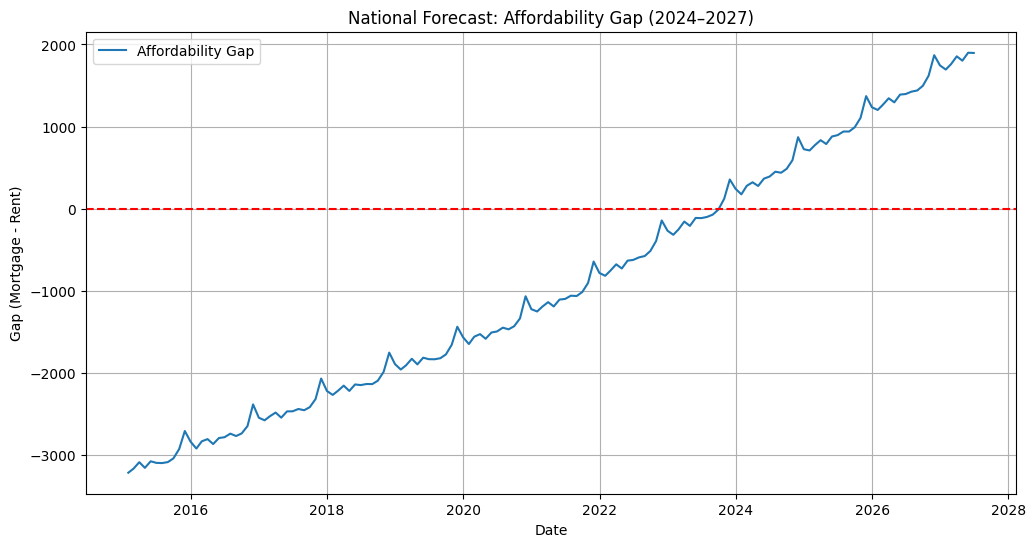

In [36]:
plt.figure(figsize=(12,6))
plt.plot(national_forecast_trend["ds"], national_forecast_trend["Affordability_Gap_Forecast"], label="Affordability Gap")
plt.axhline(0, color="red", linestyle="--")
plt.title("National Forecast: Affordability Gap (2024–2027)")
plt.xlabel("Date")
plt.ylabel("Gap (Mortgage - Rent)")
plt.legend()
plt.grid(True)
plt.show()

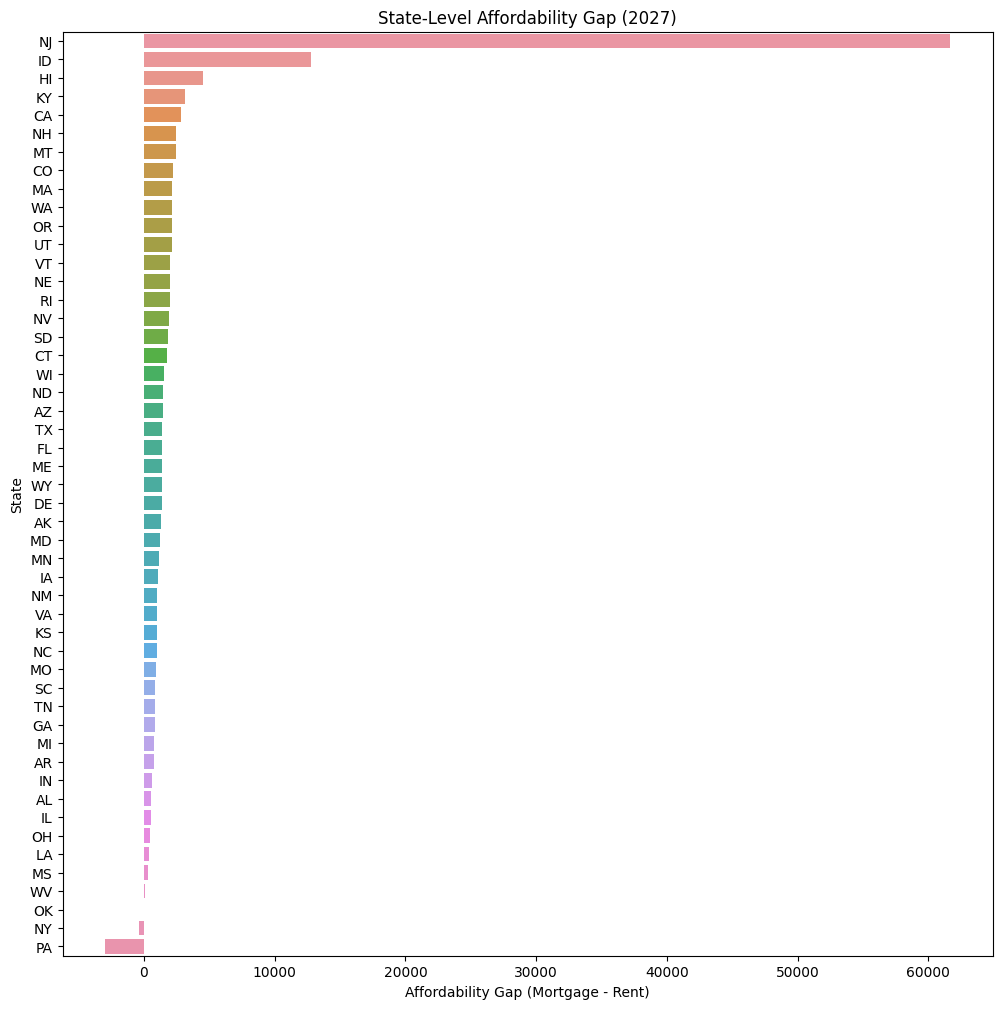

In [39]:
plt.figure(figsize=(12,12))
sns.barplot(x="Affordability_Gap_Forecast", y="StateName", data=state_2027)
plt.title("State-Level Affordability Gap (2027)")
plt.xlabel("Affordability Gap (Mortgage - Rent)")
plt.ylabel("State")
plt.show()

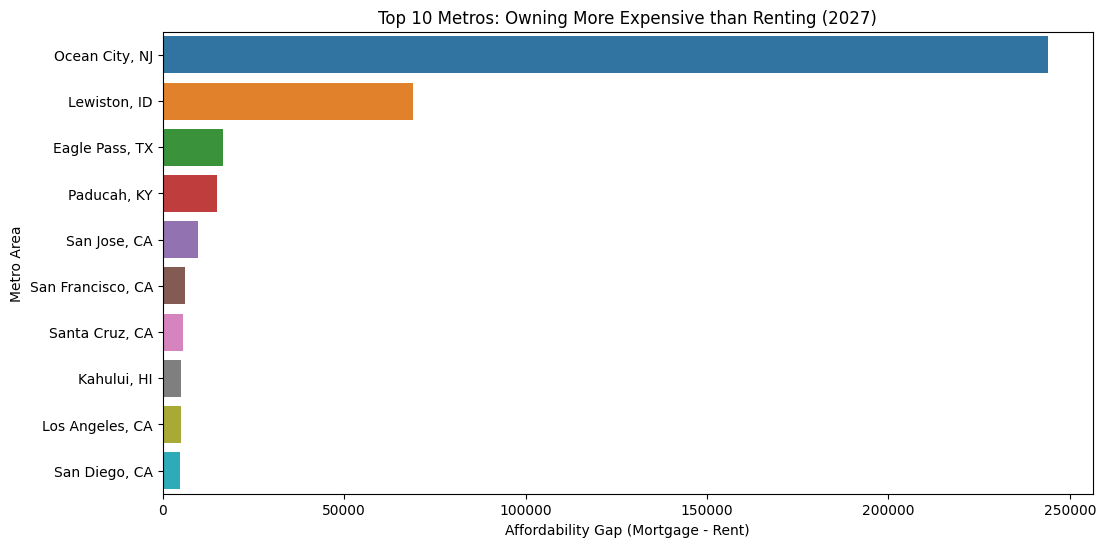

In [40]:
plt.figure(figsize=(12,6))
sns.barplot(x="Affordability_Gap_Forecast", y="RegionName", data=top_expensive_to_own)
plt.title("Top 10 Metros: Owning More Expensive than Renting (2027)")
plt.xlabel("Affordability Gap (Mortgage - Rent)")
plt.ylabel("Metro Area")
plt.show()

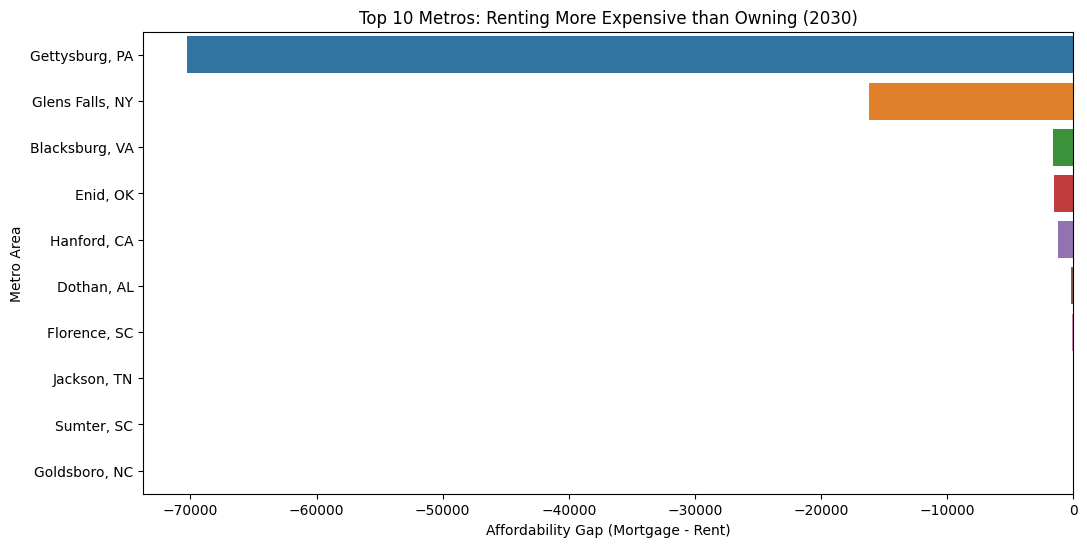

In [41]:
plt.figure(figsize=(12,6))
sns.barplot(x="Affordability_Gap_Forecast", y="RegionName", data=top_expensive_to_rent)
plt.title("Top 10 Metros: Renting More Expensive than Owning (2030)")
plt.xlabel("Affordability Gap (Mortgage - Rent)")
plt.ylabel("Metro Area")
plt.show()